In [ ]:

import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf

In [ ]:
START = "2010-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

# Define a function to load the dataset

def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    return data

In [ ]:
data = load_data('TCS.NS')
df=data
df.head()

/tmp/ipykernel_963/2158140052.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, START, TODAY)
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2010-01-04,262.774384,265.308960,261.865419,263.875600,1963682
1,2010-01-05,262.844360,265.536260,260.991501,263.945599,2014488
2,2010-01-06,256.901184,262.966701,256.254439,262.844329,3349176
3,2010-01-07,249.751953,258.491873,248.563316,257.128437,6474892
4,2010-01-08,244.647858,251.185323,243.494192,250.311331,6048178


In [ ]:

df = df.drop('Date', axis = 1)
df.head()

/tmp/ipykernel_963/2800490036.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop('Date', axis = 1)


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,262.774384,265.308960,261.865419,263.875600,1963682
1,262.844360,265.536260,260.991501,263.945599,2014488
2,256.901184,262.966701,256.254439,262.844329,3349176
3,249.751953,258.491873,248.563316,257.128437,6474892
4,244.647858,251.185323,243.494192,250.311331,6048178


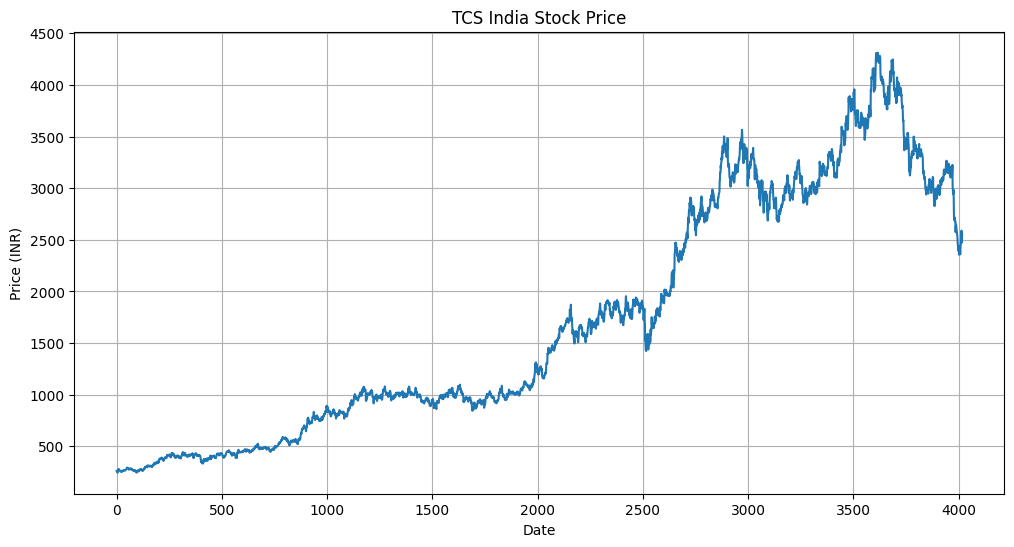

In [ ]:

plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title("TCS India Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()

In [ ]:
#Ploting moving averages of 100 days
ma100 = df.Close.rolling(100).mean()
ma100


Ticker,TCS.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4013,2915.284346
4014,2910.415508
4015,2905.156011
4016,2899.376567


Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

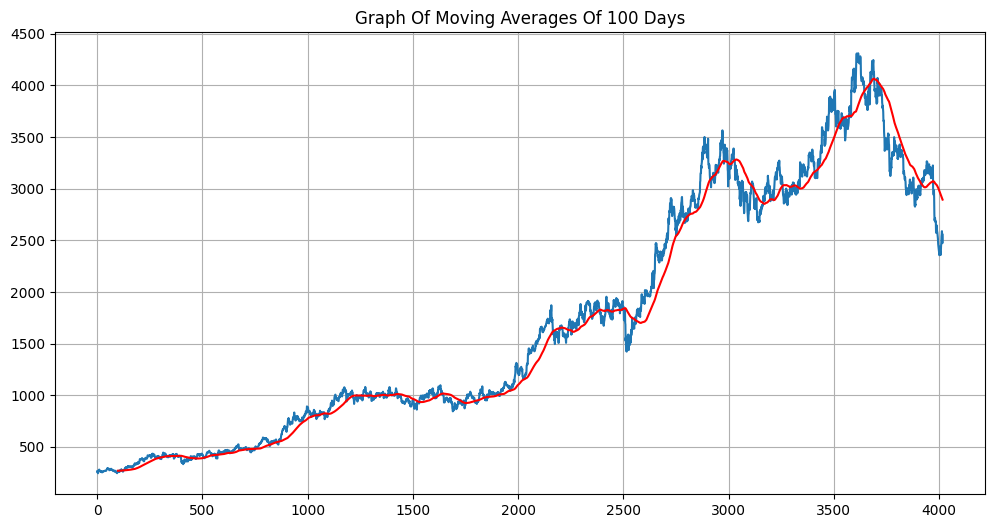

In [ ]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.grid(True)
plt.title('Graph Of Moving Averages Of 100 Days')

In [ ]:
#Defining 200 days moving average
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,TCS.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4013,2986.227578
4014,2982.343782
4015,2978.270085
4016,2973.880842


Text(0.5, 1.0, 'Comparision Of 100 Days And 200 Days Moving Averages')

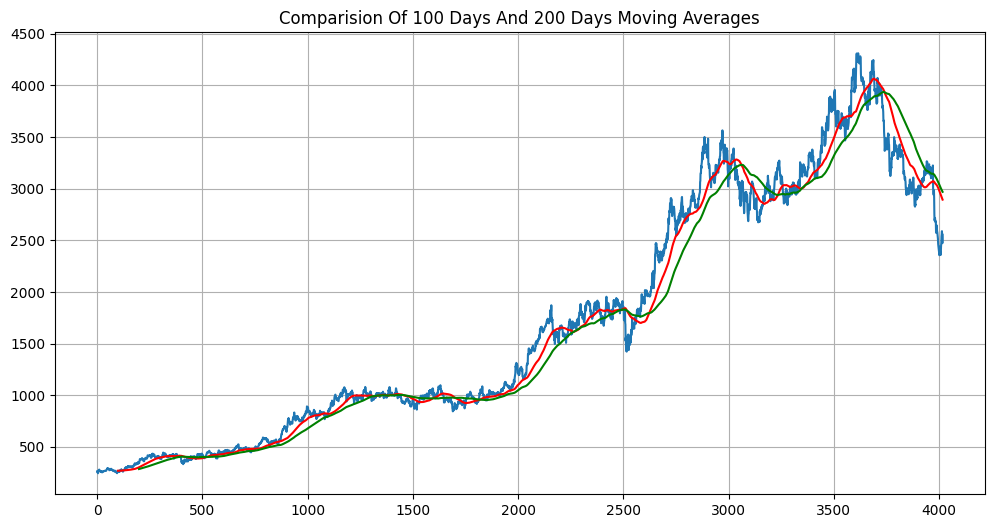

In [ ]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.grid(True)
plt.title('Comparision Of 100 Days And 200 Days Moving Averages')#plotting comparision graph with 100 days moving averages



In [ ]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])

print(train.shape)
print(test.shape)

(2812, 6)
(1206, 6)


In [ ]:
train.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2010-01-04,262.774384,265.308960,261.865419,263.875600,1963682
1,2010-01-05,262.844360,265.536260,260.991501,263.945599,2014488
2,2010-01-06,256.901184,262.966701,256.254439,262.844329,3349176
3,2010-01-07,249.751953,258.491873,248.563316,257.128437,6474892
4,2010-01-08,244.647858,251.185323,243.494192,250.311331,6048178


In [ ]:
test.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
2812,2021-05-31,2790.720703,2800.614699,2763.733705,2782.637889,1652799
2813,2021-06-01,2785.287598,2800.260794,2766.736681,2799.068365,1377441
2814,2021-06-02,2764.484375,2790.985688,2751.719619,2783.388774,2240078
2815,2021-06-03,2774.908203,2786.657161,2758.477303,2786.657161,1281706
2816,2021-06-04,2777.117188,2788.689516,2760.553864,2763.203996,1836060


In [ ]:
#Using MinMax scaler for normalization of the dataset
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

train_close = train.iloc[:, 4:5].values
test_close = test.iloc[:, 4:5].values

data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.00657202],
       [0.00659793],
       [0.0061904 ],
       ...,
       [0.92884318],
       [0.94255644],
       [0.95156231]])

In [ ]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [ ]:
x_train.shape

(2712, 100, 1)

In [ ]:
#LSTM
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [ ]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences=True
              ,input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.add(LSTM(units = 60, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))

In [ ]:
model.add(LSTM(units = 80, activation = 'relu', return_sequences=True))
model.add(Dropout(0.4))

In [ ]:
model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

In [ ]:
model.add(Dense(units = 1))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#TRAINING THE MODEL
import tensorflow as tf
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
model.fit(x_train, y_train,epochs = 100)

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 34s 290ms/step - loss: 0.0202 - mean_absolute_error: 0.0901
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step - loss: 0.0043 - mean_absolute_error: 0.0441
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 273ms/step - loss: 0.0042 - mean_absolute_error: 0.0436
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 24s 283ms/step - loss: 0.0038 - mean_absolute_error: 0.0406
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 276ms/step - loss: 0.0031 - mean_absolute_error: 0.0368
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 267ms/step - loss: 0.0033 - mean_absolute_error: 0.0367
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 42s 284ms/step - loss: 0.0028 - mean_absolute_error: 0.0349
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 272ms/step - loss: 0.0029 - mean_absolute_error: 0.0350
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 22s 257ms/step - loss: 0.0027 - mean_absolute_error: 0.0332
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 42s 274ms/step - loss: 0.0023 - mean_absolute_error: 0.0323
Epoch 11/

In [ ]:
model.save('keras_model.h5')

In [ ]:
test_close.shape

(1206, 1)

In [ ]:
past_100_days = pd.DataFrame(train_close[-100:])

In [ ]:
test_df = pd.DataFrame(test_close)

In [ ]:
#Defining the final dataset for testing by including last 100 coloums of the training dataset to get the prediction from the 1st column of the testing dataset
final_df = pd.concat([past_100_days, test_df], ignore_index=True)

In [ ]:
final_df.head()

,0
0,2544.481028
1,2526.932682
2,2588.351176
3,2666.967336
4,2719.962454


In [ ]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.09121584],
       [0.08229742],
       [0.11351152],
       ...,
       [0.10205059],
       [0.06347662],
       [0.06957526]])

In [ ]:
input_data.shape

(1306, 1)

In [ ]:
#TESTING THE MODEL
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
   x_test.append(input_data[i-100: i])
   y_test.append(input_data[i, 0])

In [ ]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(1206, 100, 1)
(1206,)


In [ ]:
# Making predictions
y_pred = model.predict(x_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step


In [ ]:
y_pred.shape

(1206, 1)

In [ ]:
y_test

array([0.21225191, 0.2206022 , 0.21263352, ..., 0.10205059, 0.06347662,
       0.06957526])

In [ ]:
y_pred

array([[0.24905497],
       [0.25027567],
       [0.25254142],
       ...,
       [0.10597472],
       [0.10688543],
       [0.10842603]], dtype=float32)

In [ ]:
scaler.scale_

array([0.00050822])

In [ ]:
scale_factor = 1/0.00041967
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor

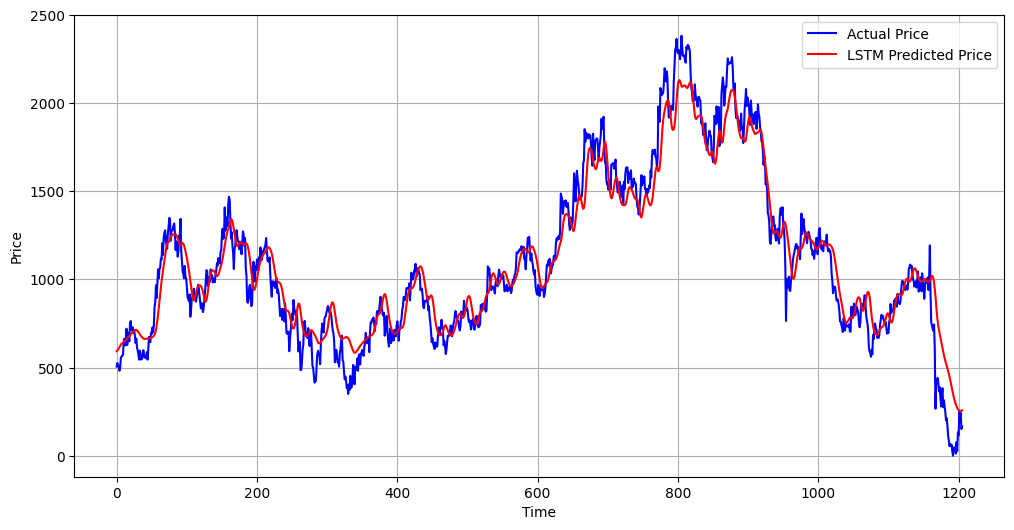

In [ ]:
#plotting the graph of predicted vs actual values
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Actual Price")
plt.plot(y_pred, 'r', label = "LSTM Predicted Price")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#MODEL EVALUATION
from sklearn.metrics import mean_absolute_error

lstm_mae = mean_absolute_error(y_test, y_pred)
lstm_mae_percentage = (lstm_mae / np.mean(y_test)) * 100
print("Mean absolute error on test set: {:.2f}%".format(lstm_mae_percentage))

Mean absolute error on test set: 8.92%


In [ ]:
#CALCULATIONG R2 SCORE
from sklearn.metrics import r2_score

# Actual values
actual = y_test

# Predicted values
predicted = y_pred

# Calculate the R2 score
lstm_r2 = r2_score(actual, predicted)

print("R2 score:", lstm_r2)

R2 score: 0.9273961857457887


In [ ]:
#ARIMA

from statsmodels.tsa.arima.model import ARIMA


arima_model = ARIMA(y_test, order=(5,1,0))
arima_fit = arima_model.fit()
arima_pred = arima_fit.predict(start=0, end=len(y_test)-1)

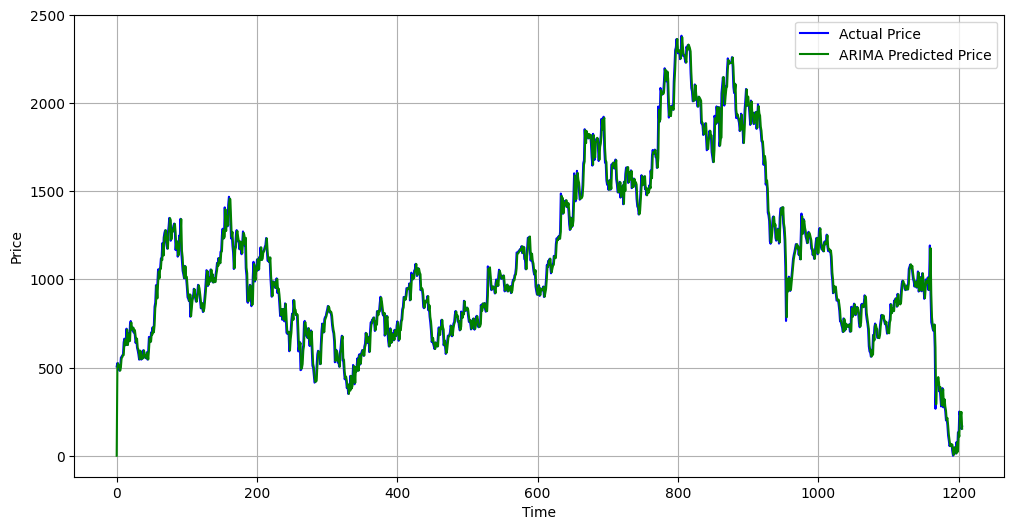

In [ ]:

plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Actual Price')
plt.plot(arima_pred, 'g', label='ARIMA Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#MODEL EVLAUATION

from sklearn.metrics import mean_absolute_error

arima_mae = mean_absolute_error(y_test, arima_pred)
arima_mae_percentage = (arima_mae / np.mean(y_test)) * 100
print("Mean absolute error on test set: {:.2f}%".format(arima_mae_percentage))



Mean absolute error on test set: 3.84%


In [ ]:
#CALCULATION R2 SCORE

from sklearn.metrics import r2_score

actual = y_test
predicted = arima_pred

arima_r2 = r2_score(actual, predicted)

print("R2 score:", arima_r2)

R2 score: 0.9852631726144889


In [ ]:
#SARIMAAA

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(y_test, order=(5,1,0), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit()
sarima_pred = sarima_fit.predict(start=0, end=len(y_test)-1)


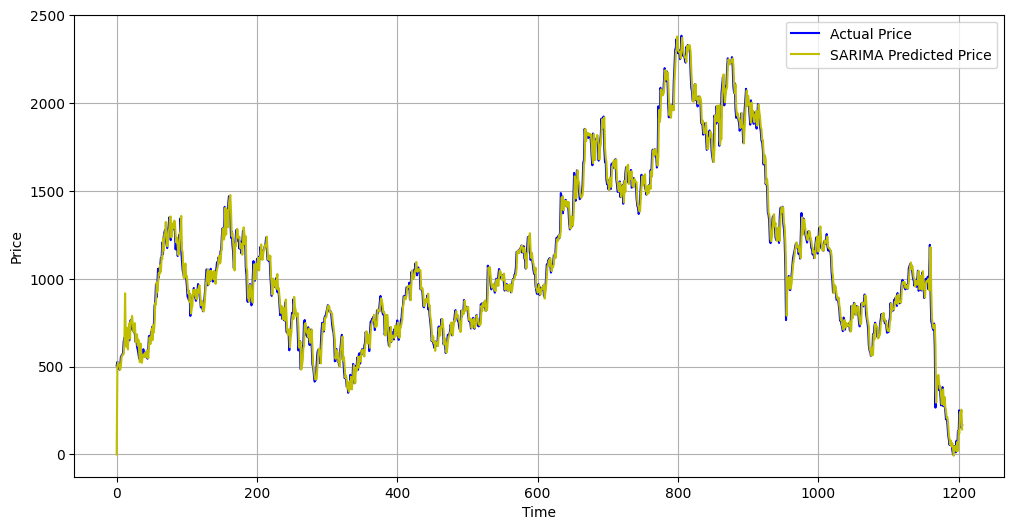

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Actual Price')
plt.plot(sarima_pred, 'y', label='SARIMA Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#MODEL EVALUATION

from sklearn.metrics import mean_absolute_error

sarima_mae = mean_absolute_error(y_test, sarima_pred)
sarima_mae_percentage = (sarima_mae / np.mean(y_test)) * 100
print("Mean absolute error on test set: {:.2f}%".format(sarima_mae_percentage))

Mean absolute error on test set: 3.93%


In [ ]:
# CALCULATE R2 SCORE

from sklearn.metrics import r2_score

actual = y_test
predicted = sarima_pred

sarima_r2 = r2_score(actual, predicted)

print("R2 score:", sarima_r2)

R2 score: 0.9845284784841718


In [ ]:
#COMPARISON


lstm_mse = mean_absolute_error(y_test, y_pred)
lstm_r2 = r2_score(y_test, y_pred)

comparison = pd.DataFrame({
    'Model': ['LSTM','ARIMA','SARIMA'],
    'MAE': [lstm_mae_percentage, arima_mae_percentage, sarima_mae_percentage],
    'R2': [lstm_r2, arima_r2, sarima_r2]
})

print(comparison)

    Model       MAE        R2
0    LSTM  8.915291  0.927396
1   ARIMA  3.837298  0.985263
2  SARIMA  3.929233  0.984528


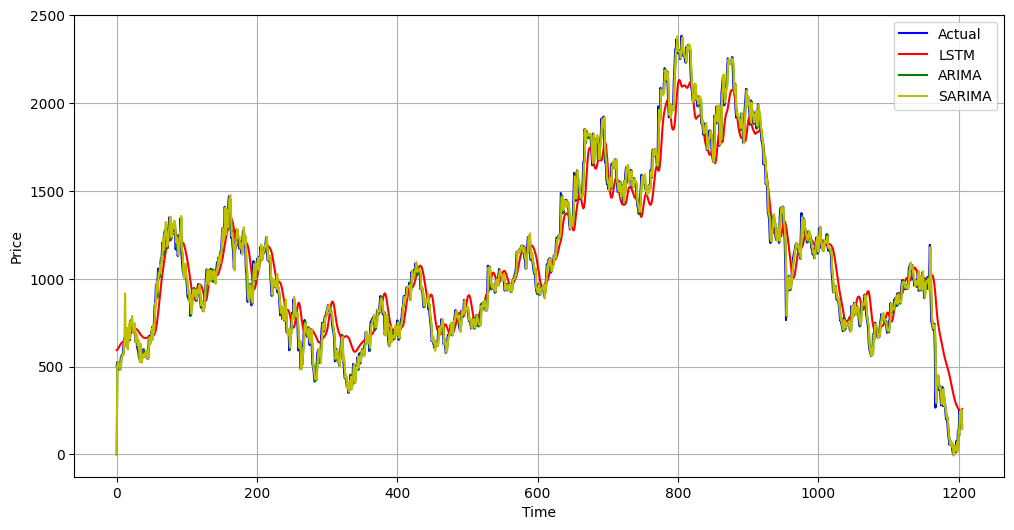

In [ ]:
#FINAL COMPARISON

plt.figure(figsize=(12,6))

plt.plot(y_test, 'b', label='Actual')
plt.plot(y_pred, 'r', label='LSTM')
plt.plot(arima_pred, 'g', label='ARIMA')
plt.plot(sarima_pred, 'y', label='SARIMA')

plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()